# Exercise 7:  Linear models

This homework assignment is designed to give you practice with linear models and the bias-variance tradeoff.

You will need to download the **unrestricted_trimmed_1_7_2020_10_50_44.csv** file from the *Homework/hcp_data* folder in the class GitHub repository.


This data is a portion of the [Human Connectome Project database](http://www.humanconnectomeproject.org/). It provides measures of cognitive tasks and brain morphology measuresments from 1206 participants. The full description of each variable is provided in the **HCP_S1200_DataDictionary_April_20_2018.csv** file in the *Homework datasets/hcp_data* folder in the class GitHub repository.

---
## 1. Loading the Data (1 point)

Use the `setwd` and `read.csv` functions to load data from the **unrestricted_trimmed_1_7_2020_10_50_44.csv** file.

Using the tidyverse tools, make a new dataframe `d1` that only inclues the subject ID (`Subject`), gender (`Gender`), Flanker Task performance (`Flanker_Unadj`), total white matter volume (`FS_Tot_WM_Vol`), and total grey matter volume (`FS_Total_GM_Vol`) variables and remove all _na_ values.

Use the `head` function to look at the first few rows of each data frame.

In [14]:
setwd("/Users/kaitlyndalbon/Desktop/Carnegie_Mellon/Courses/85732_Data_Science/DataSciencePsychNeuro/Exercise datasets/hcp_data")

library(tidyverse)
df <- read.csv("unrestricted_trimmed_1_7_2020_10_50_44.csv")

d1 <- df %>%
select(c(Subject, Gender, Flanker_Unadj, FS_Tot_WM_Vol, FS_Total_GM_Vol)) %>%
na.omit()

head(d1)

,Subject,Gender,Flanker_Unadj,FS_Tot_WM_Vol,FS_Total_GM_Vol
,<int>,<chr>,<dbl>,<int>,<int>
2,100206,M,130.42,543134,807245
3,100307,F,112.56,407292,664124
4,100408,M,121.18,500417,726206
5,100610,M,126.53,512946,762308
6,101006,F,101.85,429449,579632
7,101107,M,107.04,416995,665024


---
## 2. Initial data visualization (2 point)

Use the `pairs` function to look at all the pairwise scatterplots of the variables in `d1`. Describe which variables seem positively correlated, negatively correlated, or not correlated at all.

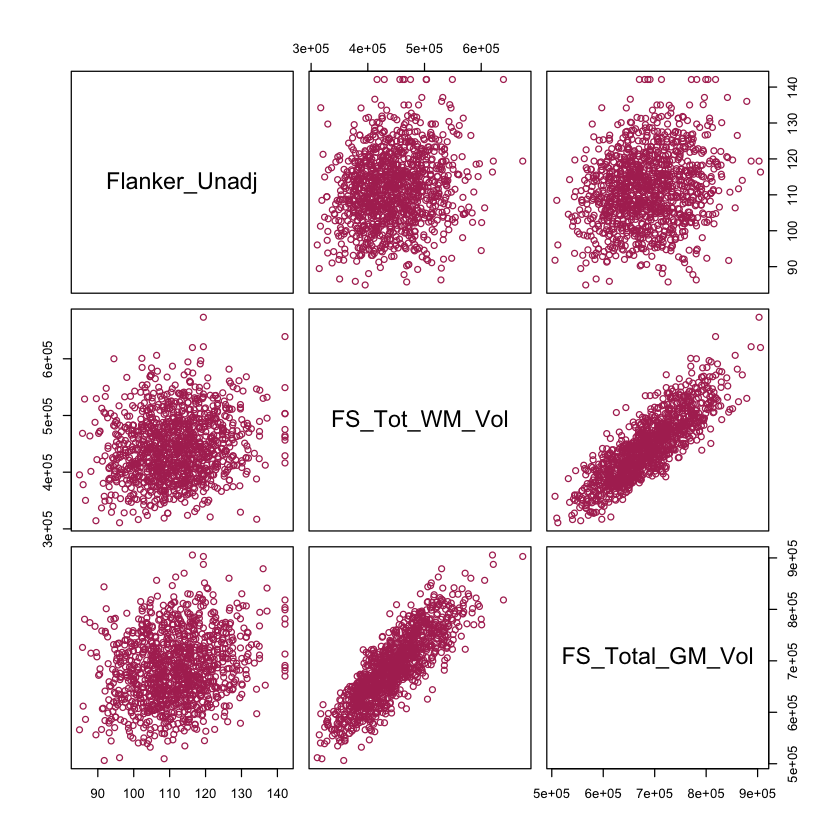

In [26]:
pairs(d1[3:5], col = "maroon")

> *Write your response here.*
> Visually, there appears to be a positive correlation between total white matter volume (FS_Tot_WM_Vol) and total grey matter volume (FS_Total_GM_Vol). On the other hand, there does not seem to be a correlation between Flanker Task performance (Flanker_Unadj) and total white matter volume (FS_Tot_WM_Vol), or Flanker Task performance (Flanker_Unadj) and total grey matter volume (FS_Total_GM_Vol).

---
## 3. Linear regression (4 points)

Use the `lm` (linear model) function to determine the association between Flanker Task performance and total grey matter volume from the `d1` data frame.

$$
Y_{flanker} = \beta_0 + \beta_1 X_{GM volume}
$$

Show the results using the `summary` function, and report the mean coefficient values for $beta_0$ \& $\beta_1$ (`coef` function) and their 95\% confidence intervals (`confint` function). Is grey matter volume significantly associated with Flanker Task performance?

---
---

### If you use Generative AI (optional)
If you use code-assisting generative AI (e.g., Copilot, GPT, Claude; more than simple google searching), follow the steps below. If you do not use generative AI, skip this section and go directly to the coding part.

#### Step 1: Write pseudocode

Write pseudocode for `lm` model (or any other variables you have to print) below.

In [ ]:
# Write out your pseudo code here

#### Step 2: Generate code using generative AI
Using your pseudocode, prompt a generative AI to create or fix the R function. Then paste **only the generated function** below.

In [ ]:
# Paste generated function here

#### Step 3: Compare and verify the code

**Question 1.** What is different between your pseudocode and generated code.
(e.g., it handled NAs differently, used a different formula arrangement, etc.)

**Question 2.** What are the input parameters and the output of the function?
(Answer to show you understand what the function takes in and returns. Be concise.)

**Question 3.** Does anything has to be changed? (Yes / No)

> *Write your response here.*

> **Q1.**

> **Q2.**

> **Q3.** Yes / No

If you answers yes to the question 3, revise the code. Don't forget to paste your final version in the code block below.

---
---

In [10]:
lm_1 <- lm(Flanker_Unadj ~ FS_Total_GM_Vol, data = d1)
summary(lm_1)

coef(lm_1) 
# coefficient converted from scientific notation: 0.0000310996547106465
confint(lm_1, level = 0.95) 
# confidence interval converted from scientific notation: 95% CI [0.00002244198, 0.00003975733]


Call:
lm(formula = Flanker_Unadj ~ FS_Total_GM_Vol, data = d1)

Residuals:
     Min       1Q   Median       3Q      Max 
-28.2280  -6.5969  -0.0119   6.5497  31.0108 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)     9.026e+01  3.041e+00  29.677  < 2e-16 ***
FS_Total_GM_Vol 3.110e-05  4.412e-06   7.048 3.18e-12 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 9.864 on 1111 degrees of freedom
Multiple R-squared:  0.0428,	Adjusted R-squared:  0.04194 
F-statistic: 49.68 on 1 and 1111 DF,  p-value: 3.177e-12


(Intercept) FS_Total_GM_Vol 
   9.025646e+01    3.109965e-05

,2.5 %,97.5 %
(Intercept),8.428917e+01,9.622375e+01
FS_Total_GM_Vol,2.244198e-05,3.975733e-05


> *Write your response here.*
> Yes, grey matter volume is associated with Flanker Task performance (p < .001).

---
## 4. Plotting (2 points)

Use `ggplot` to plot the `FS_Total_GM_Vol` variable (x axis) against the `Flanker_Unadj` variable (y axis), as well as the regression line with confidence intervals on the regrssion line. Qualitatively describe what you see.

`geom_smooth()` using formula = 'y ~ x'


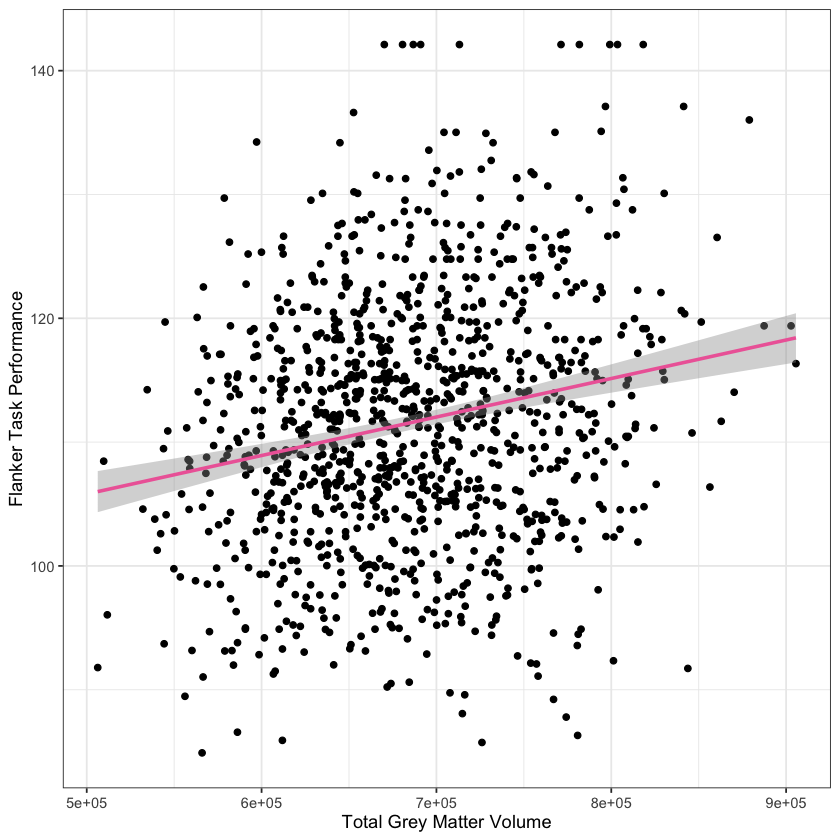

In [24]:
plot <- ggplot(d1, aes(x = FS_Total_GM_Vol, y = Flanker_Unadj)) +
    geom_point() +
    geom_smooth(method = "lm", se = TRUE, col = "hotpink2") +
    labs(x = "Total Grey Matter Volume", y = "Flanker Task Performance") +
    theme_bw() 

plot

> *Write your response here.*
> There is a wide dispersion of datapoints, with some participants performing at ceiling and floor. Most of the data cluster between 100 and 120 on the unadjusted Flanker scores, and around 6e+05 to 8e+05 of grey matter volume. Overall, there is a positive linear relationship between task performance and grey matter volume. 

---

## 5. Reflection (1 point)

What do you conclude based on the analyses above?

> *Write your response here.*
> Based solely on visual inspection, in the first pairwise comparison plot, there seemed to be no correlation between grey matter volume and Flanker Task performance. Upon running the linear regression model, however, a significant linear relationship was found between both variables. While this seems promising, there is a low percentage of variance explained (R-squared = 0.042), suggesting that grey matter volume alone provides limited explanatory power in predicting Flanker Task performance. 

**DUE:** 11:59pm EST, Feb 19, 2026

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> *I did not collaborate with any of my classmates on this assignment.*